# Principal component analysis
---
PCA uses linear algebra to transform data into new features called principal components. It finds these by calculating eigenvectors (directions) and eigenvalues (importance) from the covariance matrix. PCA selects the top components with the highest eigenvalues and projects the data onto them simplify the dataset.

Source link: https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/

Source link: https://www.geeksforgeeks.org/machine-learning/normalization-vs-standardization/

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL.ImageColor import colormap

In [2]:
data = pd.read_csv('../dataset/cleaned_data.csv')
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
4,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6
8632,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8633,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8634,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


### Standardize the Data
---
Different features may have different units and scales like salary vs. age. To compare them fairly PCA first standardizes the data by making each feature have:

- A mean of 0
- A standard deviation of 1

Standardization or Z-Score Normalization is the transformation of features by subtracting from mean and dividing by standard deviation. This is often called as Z-score.

$$ Z = \frac{X - \mu}{\sigma} $$

Where:

$$ Z - \text{the observation} $$
$$ \mu - \text{mean value of the feature values} $$
$$ \sigma - \text{standard deviation} $$

In [3]:
y = data['CUST_ID']
X = data.drop(columns=['CUST_ID'])

In [4]:
X_scaled = (X - X.mean()) / X.std(ddof=0)
X_scaled

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.744625,-0.370047,-0.429184,-0.359160,-0.354826,-0.468655,-0.820769,-0.686280,-0.717179,-0.681953,-0.479437,-0.517623,-0.962575,-0.543942,-0.305508,-0.537727,0.355181
1,0.764152,0.067679,-0.473208,-0.359160,-0.458839,2.568556,-1.236139,-0.686280,-0.926522,0.557022,0.099258,-0.597054,0.677204,0.796852,0.087689,0.212380,0.355181
2,0.426602,0.505405,-0.116413,0.099909,-0.458839,-0.468655,1.256077,2.646651,-0.926522,-0.681953,-0.479437,-0.120467,0.813852,-0.399503,-0.099906,-0.537727,0.355181
3,-0.373910,0.505405,-0.465825,-0.349660,-0.458839,-0.468655,-1.028455,-0.408536,-0.926522,-0.681953,-0.479437,-0.557339,-0.907916,-0.380165,-0.261131,-0.537727,0.355181
4,0.099551,0.505405,0.142062,-0.359160,0.994815,-0.468655,0.425339,-0.686280,0.538882,-0.681953,-0.479437,-0.279329,-0.743938,-0.132119,0.650363,-0.537727,0.355181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,-0.761342,-1.902089,-0.463563,-0.346751,-0.458839,-0.468655,-0.820769,-0.130790,-0.926522,-0.681953,-0.479437,-0.557339,-1.099224,-0.593143,-0.345988,-0.537727,-4.221800
8632,-0.750546,0.505405,-0.338865,-0.359160,-0.141436,-0.468655,1.256077,-0.686280,1.166912,-0.681953,-0.479437,-0.358760,-0.962575,-0.501396,-0.343706,1.150015,-4.221800
8633,-0.752977,-0.297095,-0.406572,-0.359160,-0.301402,-0.468655,0.840707,-0.686280,0.748227,-0.681953,-0.479437,-0.398476,-0.962575,-0.585367,-0.329572,0.306144,-4.221800
8634,-0.757721,-0.297095,-0.473208,-0.359160,-0.458839,-0.451422,-1.236139,-0.686280,-0.926522,0.144032,-0.190089,-0.597054,-1.099224,-0.595238,-0.340811,0.306144,-4.221800


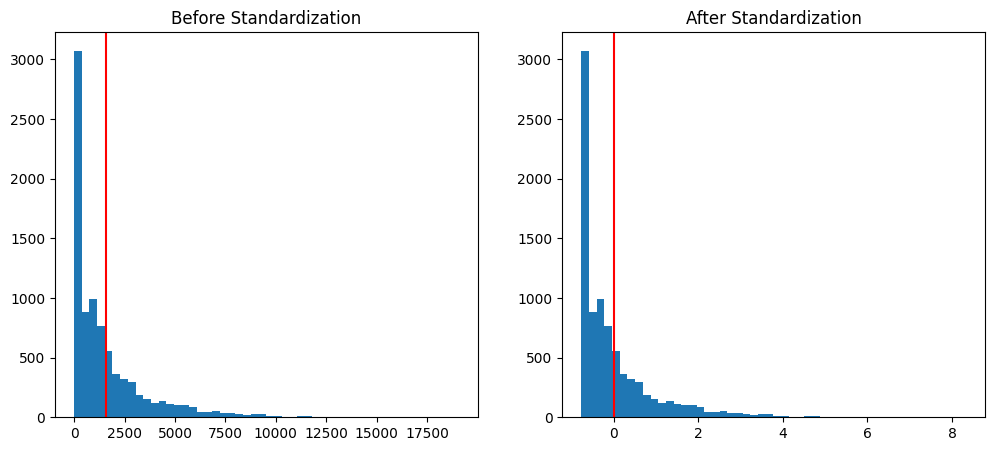

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data["BALANCE"], bins=50)
plt.axvline(data["BALANCE"].mean(), color='red')
plt.title("Before Standardization")

plt.subplot(1,2,2)
plt.hist(X_scaled["BALANCE"], bins=50)
plt.axvline(0, color='red')
plt.title("After Standardization")

plt.show()

### Why Standardization Is Important for PCA

Principal Component Analysis relies on the covariance matrix, which measures relationships between features. If the features have different scales, variables with larger magnitudes would dominate the covariance calculation.

Standardization solves this problem by ensuring that all features contribute equally to the analysis. By centering the data around zero and scaling the variance to one, PCA can identify the true directions of maximum variance in the dataset rather than being biased by feature scale.

The histogram visualization clearly shows this effect: the original distribution may be shifted and unevenly scaled, while the standardized distribution is centered around zero and normalized.

### Calculate Covariance Matrix
---

$$\LARGE
cov(x_j, x_k) =
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)
$$

### Where:

- $cov(x_j, x_k)$ – covariance between feature $j$ and feature $k$.

- $n$ – number of observations (data points in the dataset).

- $i$ – index of the observation.

- $x_{ij}$ – value of feature $j$ for observation $i$.

- $x_{ik}$ – value of feature $k$ for observation $i$.

- $\bar{x}_j$ – mean value of feature $j$.

- $\bar{x}_k$ – mean value of feature $k$.

- $(x_{ij} - \bar{x}_j)$ – deviation of feature $j$ from its mean.

- $(x_{ik} - \bar{x}_k)$ – deviation of feature $k$ from its mean.

- $\sum_{i=1}^{n}$ – sum of all observations

- $\frac{1}{n-1}$ – normalization factor used when computing the sample covariance.
